# Aula 1 - Aprendizado Não Supervisionado - Criando nosso primeiro algoritmo de Clustering ($K$-Means Clustering)

Prof. Dr. Ahirton Lopes

Baseado no original de Dennis Sun (Universidade de Stanford, 2024)

Ref. https://www.kaggle.com/code/parulpandey/penguin-dataset-the-new-iris

Ref. https://web.stanford.edu/class/stats202/intro.html


O dataset iris, contendo medidas de diferentes espécies de íris de flores, era frequentemente utilizado como um exemplo padrão para demonstrar algoritmos de classificação e clustering.

No entanto, o dataset penguins tem ganhado popularidade como uma alternativa mais interessante e rica em características. Ele oferece mais dimensões para explorar e uma aplicação mais diversificada em comparação com o dataset iris.

Pinguins são animais icônicos e de interesse popular, o que torna o dataset penguins interessante e relevante para uma variedade de públicos. Além disso, o estudo e conservação de pinguins são áreas de pesquisa ativas, o que adiciona um elemento de atualidade e interesse aos dados.

## Lendo os dados

In [17]:
import numpy as np
import pandas as pd

data_dir = "C:/Users/Tega/Documents/Projetos/posGraduacao_MLE/Fase_3/Nao_Supervisionado/penguins.csv"
df_penguins = pd.read_csv(data_dir)
df_penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


O dataset penguins contém informações sobre diferentes espécies de pinguins, incluindo medidas físicas como comprimento do bico, profundidade do bico, comprimento da nadadeira, e peso. Essas características oferecem uma variedade de dimensões para explorar e aplicar algoritmos de clustering, permitindo uma análise mais abrangente.

Vamos nos concentrar em apenas duas das variáveis, a profundidade do bico e o comprimento da nadadeira, para que possamos visualizar facilmente os dados. Com base no gráfico de dispersão abaixo, quantos clusters existem neste conjunto de dados? Você pode criar um algoritmo que identifique automaticamente esses clusters?

<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

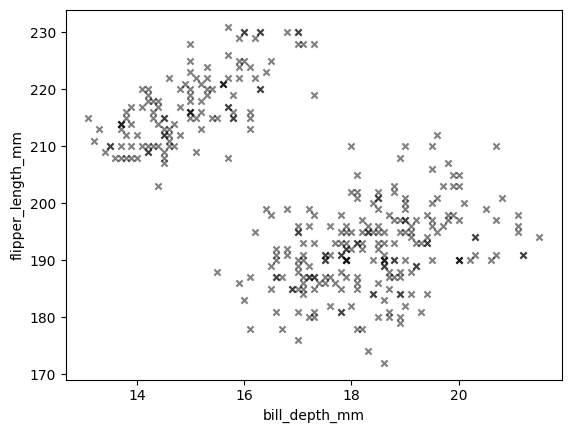

In [18]:
# Olhando apenas profundo do bico e o comprimento da nadadeira, 
X_train = df_penguins[["bill_depth_mm", "flipper_length_mm"]].dropna()
X_train.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                     c="black", marker="x", alpha=.5)

Essas duas variáveis estão em escalas muito diferentes, então precisaremos normalizá-las primeiro (num processo conhecido como *feature scaling*).

<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

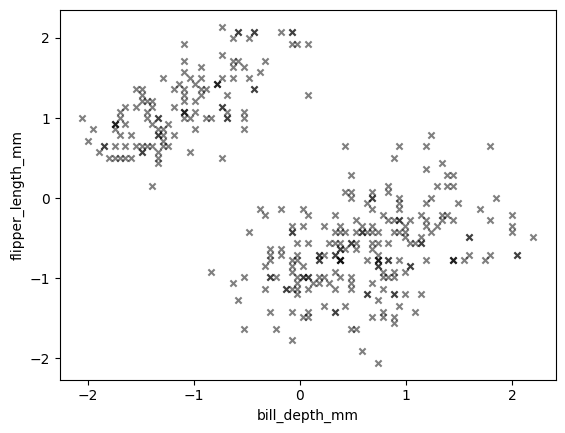

In [19]:
X_train_scaled = df_penguins[["bill_depth_mm", "flipper_length_mm"]].dropna()
X_train_scaled = (X_train_scaled - X_train_scaled.mean()) / X_train_scaled.std()
X_train_scaled.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                     c="black", marker="x", alpha=.5)

<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

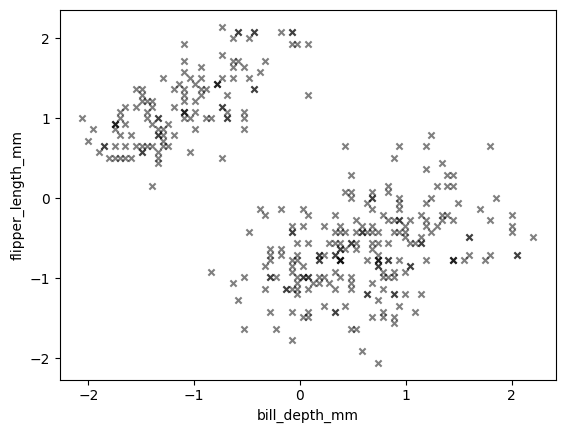

In [20]:
# A mesma normalização, mas usando o StandardScaler do sklearn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_standardscaler = df_penguins[["bill_depth_mm", "flipper_length_mm"]].dropna()
X_train_standardscaler = scaler.fit_transform(X_train_standardscaler)
X_train_standardscaler = pd.DataFrame(X_train_standardscaler, columns=["bill_depth_mm", "flipper_length_mm"])
X_train_standardscaler.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                     c="black", marker="x", alpha=.5)

## Implementando K-Means do zero (from scratch)

$K$-means é um algoritmo para encontrar clusters em dados. A ideia por trás de $k$-means é simples: cada cluster tem um ponto “central” chamado **centróide**, e cada observação é atribuída ao cluster de seu centróide mais próximo. O desafio é encontrar os centróides certos. O algoritmo $k$-means começa com uma estimativa aleatória para os centróides e os melhora iterativamente.

As etapas são as seguintes:

1. Inicialize $k$ centróides aleatoriamente.
2. Atribua cada ponto ao cluster do centróide mais próximo.
3. (Após a reatribuição, cada centróide pode não estar mais no centro do seu cluster.) Recalcule cada centróide com base nos pontos atribuídos ao seu cluster.
4. Repita as etapas 2 e 3 até que nenhum ponto mude de cluster.

Primeiro, implementaremos o algoritmo $k$-means do zero. Primeiro, vamos amostrar 3 observações aleatoriamente dos dados dos pinguins para servir como centróides iniciais.

,bill_depth_mm,flipper_length_mm
r,0.683024,0.006030
b,-0.734846,1.499447
y,0.075365,-0.207315


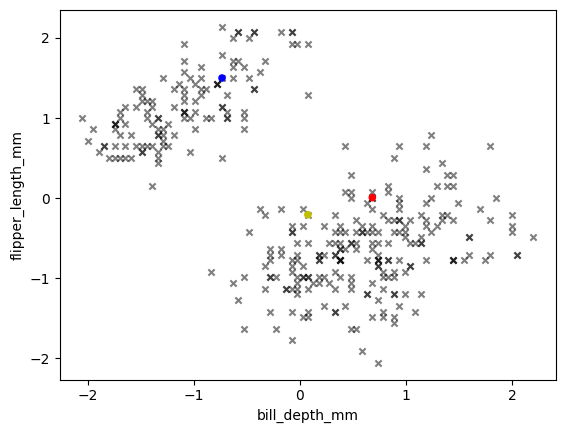

In [21]:
# Inicializando 3 centróides aleatoriamente a partir dos dados.
centroids = X_train_scaled.sample(3)

# Chamando os três clusters de "vermelho", "azul" e "amarelo" por conveniência.
centroids.index = ["r", "b", "y"]

# Plotando esses centróides.
ax = X_train_scaled.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                                 c="black", marker="x", alpha=.5)
centroids.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                       c=centroids.index, ax=ax)

centroids

Agora atribuímos cada ponto ao cluster do seu centróide mais próximo.

In [22]:
# Encontra o centróide mais próximo de uma determinada observação.
def get_nearest_centroid(obs):
    dists = np.sqrt(((obs - centroids) ** 2).sum(axis=1))
    return dists.idxmin()

get_nearest_centroid(X_train_scaled.loc[0])

'y'

<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

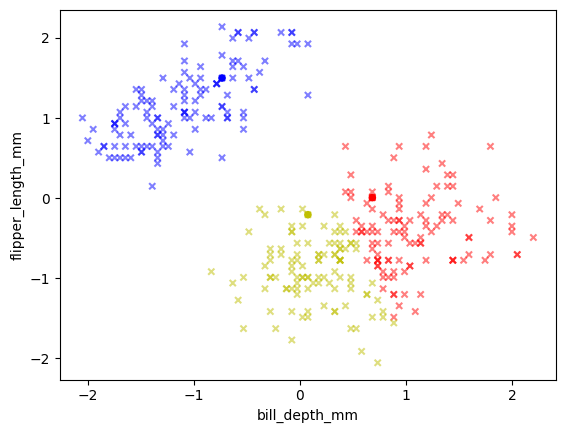

In [23]:
# Aplicando a função a todo o conjunto de dados.
clusters = X_train_scaled.apply(get_nearest_centroid, axis=1)

# Plotando as atribuições do cluster.
ax = X_train_scaled.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                                 c=clusters, marker="x", alpha=.5)
centroids.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                       c=centroids.index, ax=ax)

Observe que alguns dos centróides não estão mais no centro de seus aglomerados. Podemos corrigir isso redefinindo o centróide como a média dos pontos no seu cluster.

,bill_depth_mm,flipper_length_mm
b,-1.098371,1.157170
r,1.069756,-0.395487
y,0.134125,-0.921150


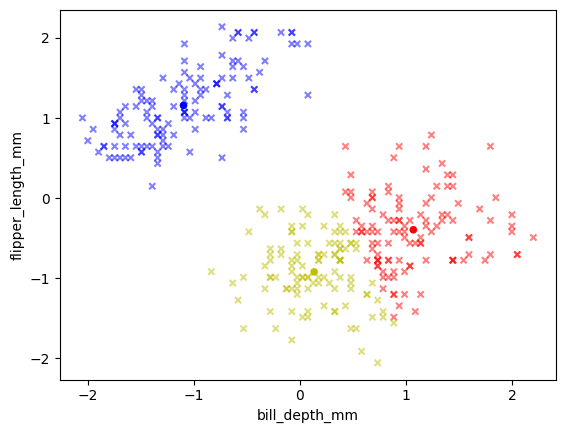

In [24]:
# Calculando o tamanho médio de cada cluster.
centroids = X_train_scaled.groupby(clusters).mean()

# Vamos plotar os centróides!
ax = X_train_scaled.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                                 c=clusters, marker="x", alpha=.5)
centroids.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                       c=centroids.index, ax=ax)

centroids

Agora, pode haver alguns pontos que não estão mais atribuídos ao seu centróide mais próximo, então temos que voltar e reatribuir os clusters. Mas isso pode fazer com que os centróides não estejam mais no centro do seu aglomerado, por isso temos que recalcular os centróides. E assim por diante. Esse processo continua até que as atribuições de cluster parem de mudar.

<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

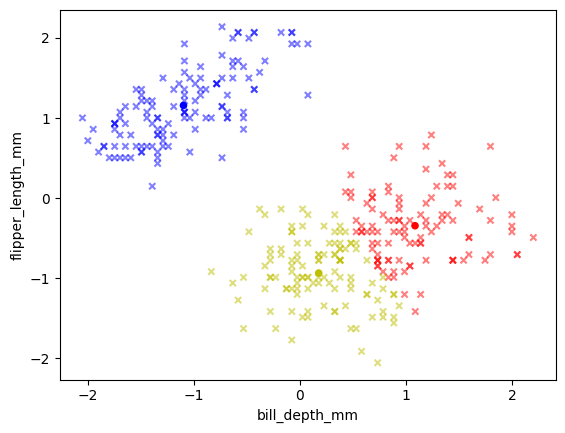

In [25]:
# Atribua pontos ao centróide mais próximo.
clusters = X_train_scaled.apply(get_nearest_centroid, axis=1)

# Recalculando os centróides com base nos clusters.
centroids = X_train_scaled.groupby(clusters).mean()

# Traçando as atribuições atuais do cluster e centróides.
ax = X_train_scaled.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                                 c=clusters, marker="x", alpha=.5)
centroids.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                       c=centroids.index, ax=ax)

Podemos executar o código na célula acima repetidamente até que os clusters parem de mudar. Esta é a atribuição final do cluster.

# $K$-Means em _scikit-learn_

Raramente precisamos implementar o algoritmo $k$-means do zero porque ele está disponível no _scikit-learn_. A API para o modelo $k$-means do _scikit-learn_ é semelhante à API para modelos de aprendizagem supervisionada, como $k$-vizinhos mais próximos, exceto que o método `.fit()` aceita apenas `X`, não `X ` e `y`. Isso faz sentido porque no aprendizado não supervisionado não há rótulos `y` nos dados de treinamento.

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3, n_init=10)
pipeline = make_pipeline(
    StandardScaler(),
    model
)

pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. Th

In [27]:
# Extraindo os centróides e os clusters.
centroids = model.cluster_centers_
clusters = model.labels_

print("Centróides:\n", centroids)
print("Clusters:\n", clusters)

Centróides:
 [[ 0.27454062 -0.91981165]
 [-1.09998045  1.15886506]
 [ 1.15893121 -0.2268899 ]]
Clusters:
 [0 0 0 2 2 0 2 0 2 0 0 0 2 2 0 2 2 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 2 2 0
 0 0 0 2 0 2 0 0 0 0 0 2 0 0 0 2 0 0 0 2 0 2 0 2 0 0 0 0 0 2 0 2 2 0 0 2 0
 2 0 0 0 2 0 0 0 2 0 2 2 0 2 0 2 2 0 0 0 2 0 2 0 0 0 2 0 2 2 0 0 2 0 2 0 2
 0 2 2 2 0 2 0 0 0 2 0 2 0 2 0 0 0 2 0 2 0 2 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 2 0 2 0 0 2 2 2 0 2 0 2 0 2 2 0 0 0 0 0
 0 2 0 2 2 2 0 2 0 2 0 2 2 0 0 2 0 2 2 0 2 0 0 2 0 2 0 0 0 2 0 2 0 2 0 2 2
 2 2 0 0 2 2 0 2 2]


<Axes: xlabel='bill_depth_mm', ylabel='flipper_length_mm'>

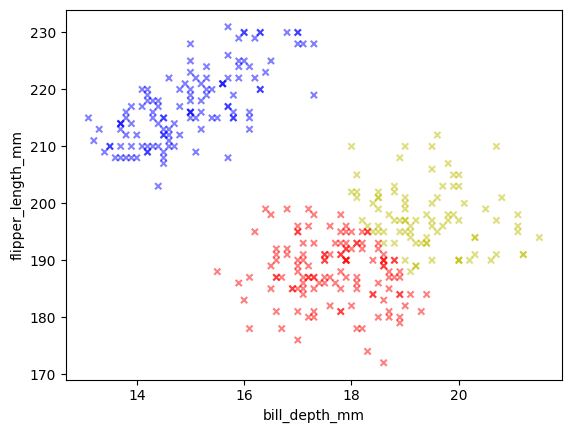

In [28]:
# Mapeando os números dos clusters para cores.
clusters = pd.Series(clusters).map({
    0: "r",
    1: "b",
    2: "y"
})

# Plotando os dados
X_train.plot.scatter(x="bill_depth_mm", y="flipper_length_mm",
                     c=clusters, marker="x", alpha=.5)

Podemos chamar `.predict()` para obter a atribuição de cluster para uma nova observação. Por exemplo, considere um pinguim com bico de 15 mm de profundidade e comprimento de nadadeira de 210 mm. Visualmente, é óbvio a qual cluster esse pinguim deve ser atribuído. Vamos verificar se este pinguim está realmente atribuído a esse cluster.

In [34]:
pipeline.predict([[18, 210]])

c:\Users\Tega\Documents\Projetos\posGraduacao_MLE\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

Observe que `.predict()` simplesmente atribui a observação de teste ao cluster mais próximo sem recalcular os centróides. (Se esta observação estivesse nos dados de treinamento, então atribuí-la a um cluster moveria o centróide, o que por sua vez mudaria a atribuição dos outros pontos aos clusters, e assim por diante.)